<a href="https://colab.research.google.com/github/M7office/visualization/blob/assignment-3/Viz%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

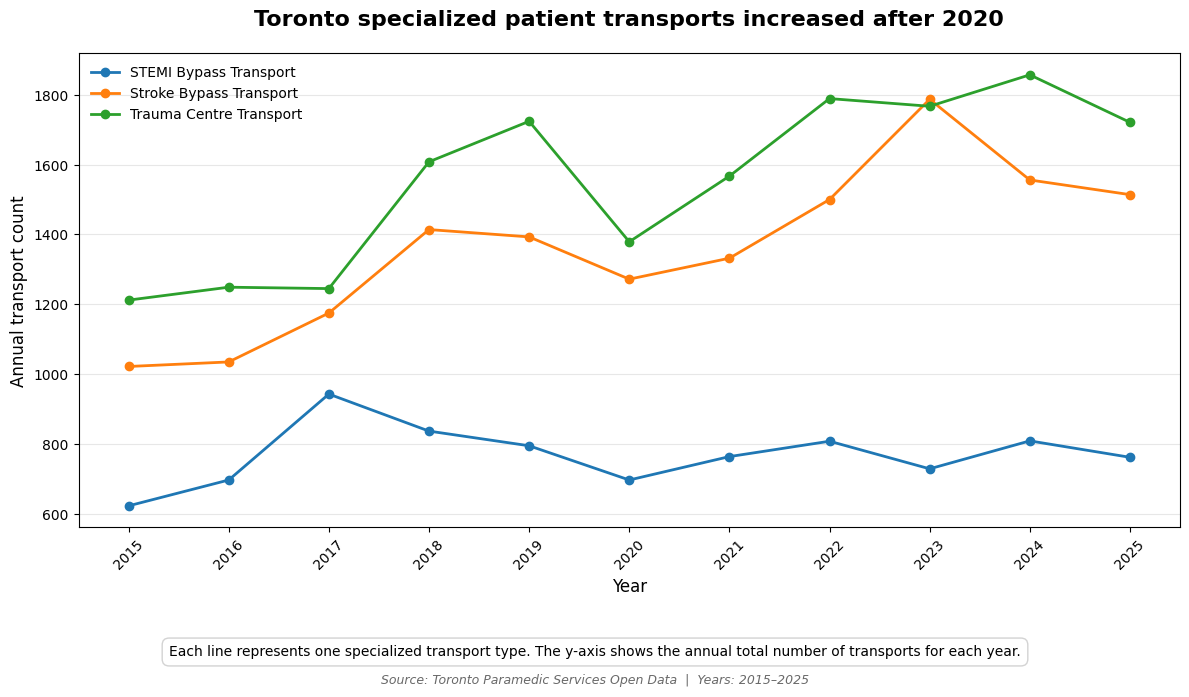

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "specialized-patient-transports-data-2015-2025.xlsx"

sheets = [
    "STEMI Bypass Transports",
    "Stroke Bypass Transports",
    "Trauma Centre Transports"
]

df = pd.concat(
    [pd.read_excel(file_path, sheet_name=s) for s in sheets],
    ignore_index=True
)

annual_summary = (
    df.groupby(["Year", "Specialized Transport Type"])["Count"]
    .sum()
    .reset_index()
)

pivot_df = annual_summary.pivot(
    index="Year",
    columns="Specialized Transport Type",
    values="Count"
)

fig, ax = plt.subplots(figsize=(12, 7))

for transport_type in pivot_df.columns:
    ax.plot(
        pivot_df.index,
        pivot_df[transport_type],
        marker="o",
        linewidth=2,
        label=transport_type
    )

ax.set_title(
    "Toronto specialized patient transports increased after 2020",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual transport count", fontsize=12)

ax.set_xticks(pivot_df.index)
ax.tick_params(axis="x", rotation=45)

ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left", frameon=False)

fig.text(
    0.5,
    0.055,
    "Each line represents one specialized transport type. "
    "The y-axis shows the annual total number of transports for each year.",
    ha="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="lightgray"
    )
)

fig.text(
    0.5,
    0.015,
    "Source: Toronto Paramedic Services Open Data  |  Years: 2015–2025",
    ha="center",
    fontsize=9,
    style="italic",
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("annual_transport_trends_annotated.png", dpi=300, bbox_inches="tight")
plt.show()

**What software did you use to create your data visualization?**

Python

**Who is your intended audience?**

My intended audience is emergency medical service planners, and Toronto health system decision-makers.

**What information or message are you trying to convey with your visualization?**

- The figure highlights differences in long-term growth among the three transport categories.
- The main message is that stroke bypass and trauma centre transports increased substantially after 2020, while STEMI bypass transports remained relatively stable.

**What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots?**

- I selected a line chart because the primary goal was to show changes over time.
- Different colors and markers were used to distinguish transport types.
- An annotation box and source note were included to provide context.

**How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization?**

The plot was created using Python code.

**How did you ensure that your data visualization is accessible?**

 Data categories are identified by both color and labels in the legend

**Who are the individuals and communities who might be impacted by your visualization?**

Patients, paramedics, hospitals, emergency departments, and Toronto communities may be impacted. The plot could support planning for emergency transport demand.

**How did you choose which features of your chosen dataset to include or exclude from your visualization?**

- I included year, transport type, and annual transport count because these variables directly support the objective of examining long-term trends.
- Monthly data were excluded because they would make the figure more complex and distract from the overall temporal pattern.

**What ‘underwater labour’ contributed to your final data visualization product?**

- People who collected data and offered TI support for making it open online
- The hidden viz work included improving readability.